In [9]:
from sklearn.datasets import load_digits
digits = load_digits()

In [10]:
print(dir(digits))
print(digits.keys())

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [11]:
print(digits.data)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


In [12]:
digits.target

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [14]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

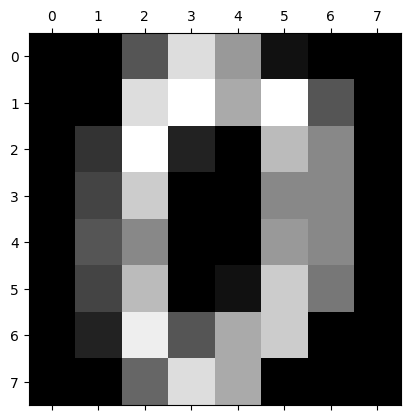

In [15]:
import matplotlib.pyplot as plt

plt.gray()
plt.matshow(digits.images[0])
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.svm import SVC
model = SVC()

In [21]:
model_linear =  SVC(kernel="linear")

In [22]:
model_linear.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
accuracy_linear = model_linear.score(X_test, y_test)
print(f"linear kernel accuracy: {accuracy_linear}")

linear kernel accuracy: 0.9777777777777777


In [28]:
model_rbf = SVC(kernel='rbf')

model_rbf.fit(X_train, y_train)

accuracy_rbf = model_rbf.score(X_test, y_test)

print("RBF Kernel Accuracy:", accuracy_rbf)

RBF Kernel Accuracy: 0.9861111111111112


In [33]:
model_polynomial = SVC(kernel='poly')

model_polynomial.fit(X_train, y_train)

accuracy_polynomial = model_polynomial.score(X_test, y_test)

print("Polynomial Kernel Accuracy:", accuracy_polynomial)


Polynomial Kernel Accuracy: 0.9916666666666667


In [34]:
model_tuned = SVC(
    kernel='rbf',
    C=10,
    gamma=0.001
)

model_tuned.fit(X_train, y_train)

accuracy_tuned = model_tuned.score(X_test, y_test)

print("Tuned Accuracy:", accuracy_tuned)

Tuned Accuracy: 0.9888888888888889


Predicted: 6
Actual: 6


<Figure size 640x480 with 0 Axes>

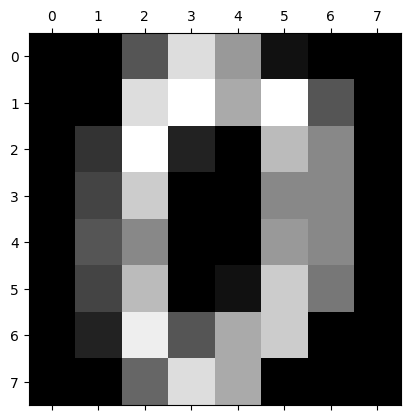

In [42]:
prediction = model_tuned.predict([X_test[0]])

print("Predicted:", prediction[0])
print("Actual:", y_test[0])

plt.gray()
plt.matshow(digits.images[0])
plt.show()

In [44]:
import pickle
with open("svm_digits_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [45]:
with open("svm_digits_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!
